Shape: (150, 6)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Species Count:
 species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Basic Stats:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.

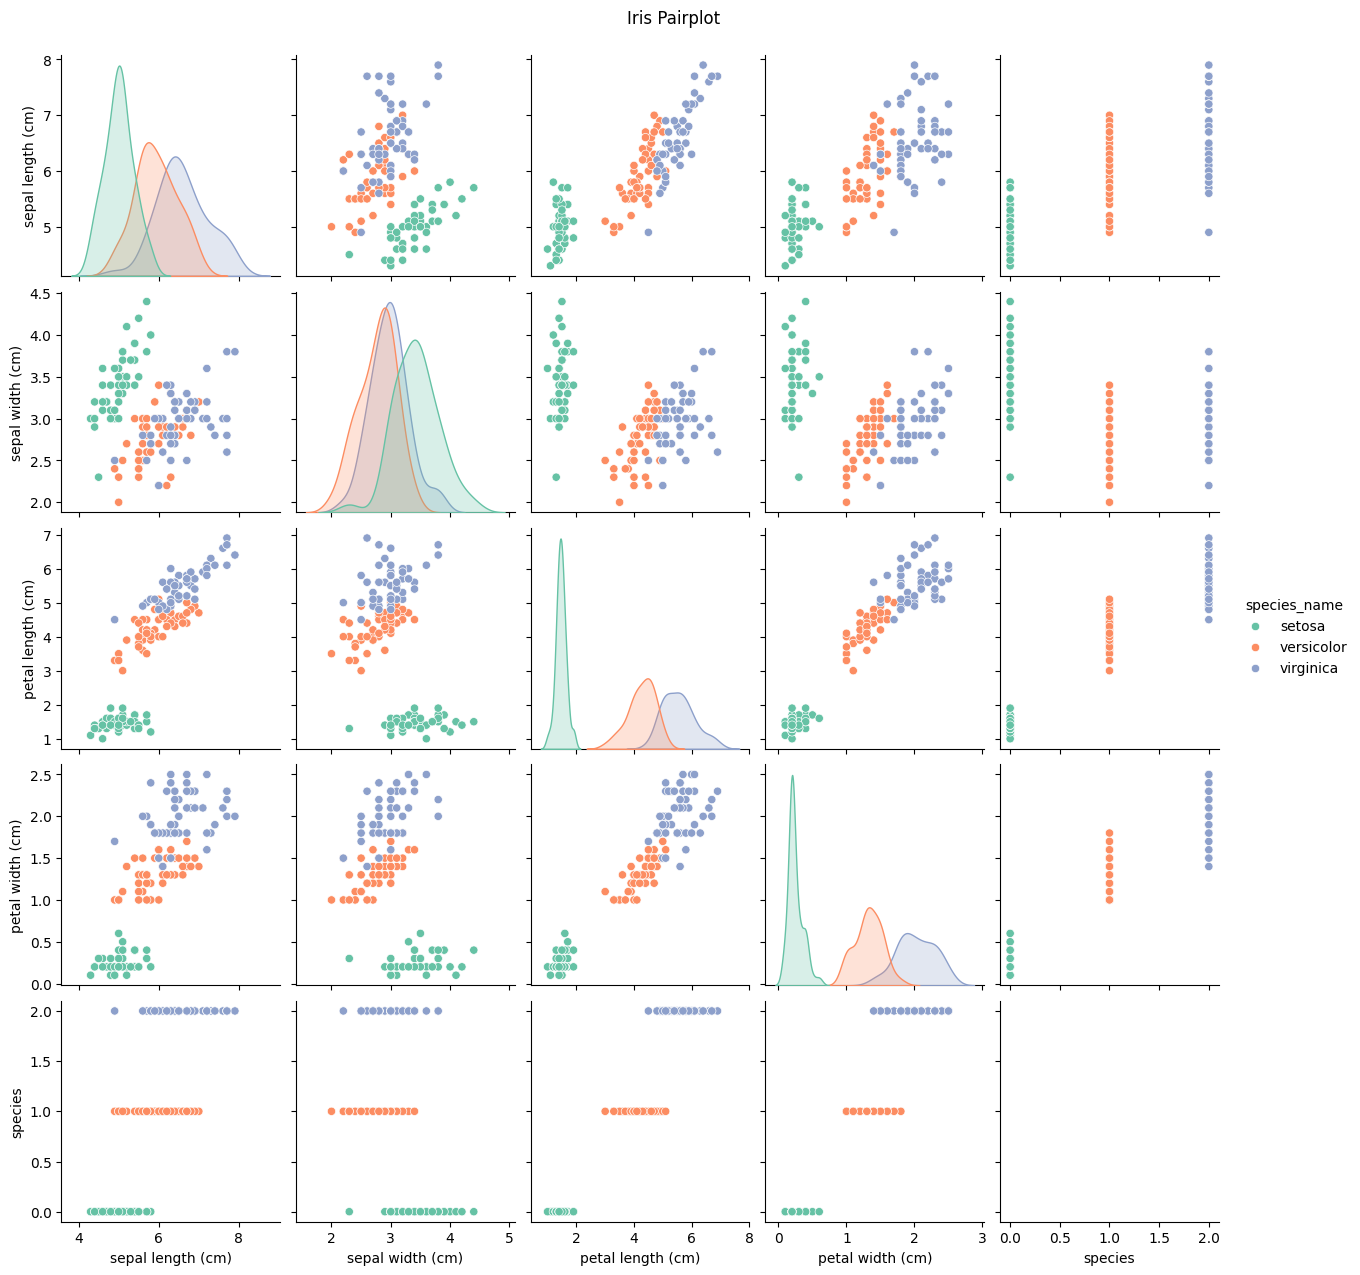

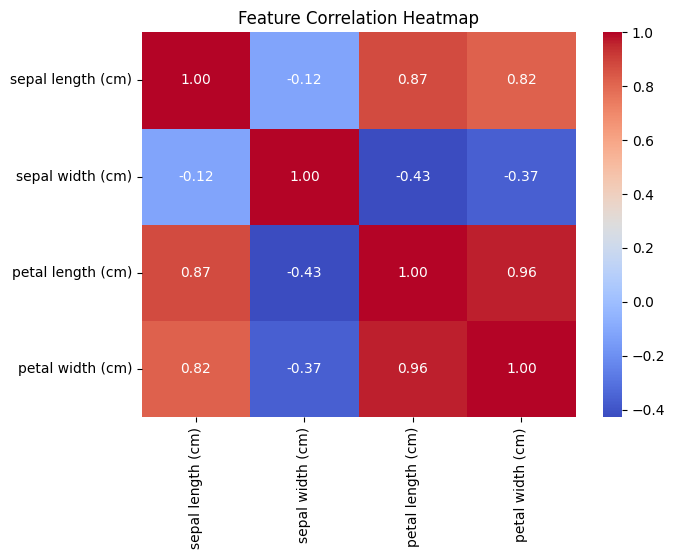


Model: KNN | Accuracy: 100.00%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Model: Decision Tree | Accuracy: 93.33%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Model: Random Forest | Accuracy: 90.00%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor   

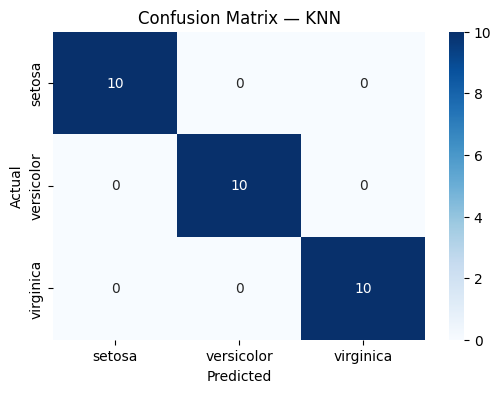

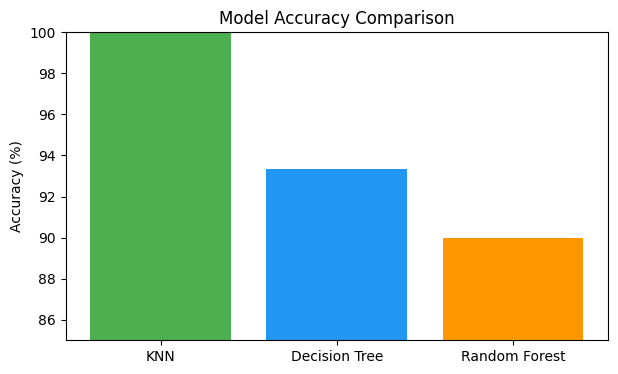


Best Model: KNN with 100.00% accuracy


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Basic exploration
print("Shape:", df.shape)
print(df.head())
print("\nSpecies Count:\n", df['species_name'].value_counts())
print("\nBasic Stats:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

# Pairplot
sns.pairplot(df, hue='species_name', palette='Set2')
plt.suptitle("Iris Pairplot", y=1.02)
plt.savefig("pairplot.png", bbox_inches='tight')
plt.show()

# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.drop(columns=['species', 'species_name']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.savefig("heatmap.png", bbox_inches='tight')
plt.show()

# Train-test split
X = df[iris.feature_names]
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

# Training and evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\nModel: {name} | Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, preds, target_names=iris.target_names))

# Best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
best_preds = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.show()

# Accuracy comparison
plt.figure(figsize=(7, 4))
plt.bar(results.keys(), [v*100 for v in results.values()],
        color=['#4CAF50', '#2196F3', '#FF9800'])
plt.ylim(85, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.savefig("model_comparison.png", bbox_inches='tight')
plt.show()

print(f"\nBest Model: {best_model_name} with {results[best_model_name]*100:.2f}% accuracy")
